# Week 5 – NLP Techniques & Sentiment Classification

## Objective
This project performs sentiment analysis on Amazon product reviews using Natural Language Processing (NLP). The workflow includes text preprocessing, feature extraction, training multiple classification models, evaluating their performance, and deploying the best model in a Streamlit dashboard for real-time sentiment prediction.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib
import re
import nltk

In [4]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to C:\Users\hania
[nltk_data]     sajjad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
import os

os.listdir("../data")

['amazon_reviews.csv']

## Load and Inspect the Dataset

In this section, we load the Amazon Reviews dataset, inspect its structure, identify the review text and sentiment label columns, and analyze the distribution of positive and negative reviews.

In [6]:
df = pd.read_csv("../data/amazon_reviews.csv")

In [7]:
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   rating            3150 non-null   int64
 1   date              3150 non-null   str  
 2   variation         3150 non-null   str  
 3   verified_reviews  3149 non-null   str  
 4   feedback          3150 non-null   int64
dtypes: int64(2), str(3)
memory usage: 599.7 KB


In [17]:
print(df.columns)

Index(['rating', 'date', 'variation', 'verified_reviews', 'feedback'], dtype='str')


### Missing Value Analysis

Missing values are checked to identify any incomplete records that may require preprocessing before model training.

In [18]:
df.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

### Handle Missing Values

Rows containing missing review text are removed because they cannot be processed for sentiment analysis.

In [13]:
df = df.dropna(subset=["verified_reviews"]).reset_index(drop=True)

### Review Text and Sentiment Columns

The **verified_reviews** column contains the customer review text, while the **feedback** column represents the sentiment label used for classification.

- **1** → Positive Review
- **0** → Negative Review

In [19]:
df[['verified_reviews', 'feedback']].head()

,verified_reviews,feedback
0,Love my Echo!,1
1,Loved it!,1
2,"Sometimes while playing a game, you can answer...",1
3,I have had a lot of fun with this thing. My 4 ...,1
4,Music,1


### Sentiment Class Distribution

The number of positive and negative reviews is calculated to understand the balance of the dataset before training classification models.

In [20]:
df['feedback'].value_counts()

feedback
1    2893
0     257
Name: count, dtype: int64

### Visualization of Sentiment Distribution

A bar chart is created to visualize the number of positive and negative reviews in the dataset. This provides a quick overview of the sentiment distribution and helps identify any class imbalance.

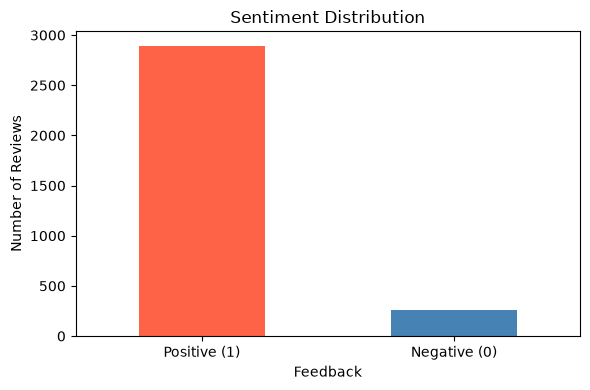

In [60]:
plt.figure(figsize=(6,4))

df["feedback"].value_counts().plot(
    kind="bar",
    color=["tomato", "steelblue"]
)

plt.title("Sentiment Distribution")
plt.xlabel("Feedback")
plt.ylabel("Number of Reviews")
plt.xticks([0,1], ["Positive (1)", "Negative (0)"], rotation=0)

plt.tight_layout()
plt.savefig("../assets/class_distribution.png", dpi=300)

plt.show()

### Observations

- The dataset contains Amazon customer reviews stored in the **verified_reviews** column.
- The **feedback** column serves as the target variable, where **1** represents a positive review and **0** represents a negative review.
- The dataset contains no significant missing values in the review or label columns.
- Examining the class distribution provides insight into whether the dataset is balanced, which is important when training classification models.

# Text Preprocessing

Raw text data often contains unnecessary characters, punctuation, numbers, and common words that do not contribute meaningful information for sentiment analysis. In this section, the review text is cleaned by removing noise, converting text to lowercase, removing punctuation, numbers, and English stopwords. The cleaned text will then be used for feature extraction and model training.

### Import English Stopwords

Stopwords are common words such as *the*, *is*, *and*, and *of* that occur frequently in text but usually carry little useful information for sentiment classification. Removing them helps the model focus on more meaningful words.

In [1]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

### Define a Text Cleaning Function

A custom function is created to preprocess each review by:
- Converting text to lowercase
- Removing punctuation and special characters
- Removing numbers
- Splitting the text into individual words
- Removing English stopwords
- Joining the cleaned words back into a sentence

In [10]:
def clean_text(text):
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Split into words
    words = text.split()
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # Join words back into text
    text = " ".join(words)
    
    return text

### Apply Text Cleaning

The preprocessing function is applied to every review in the **verified_reviews** column. The cleaned reviews are stored in a new column named **cleaned_reviews**, while the original reviews are preserved.

In [14]:
df["cleaned_reviews"] = df["verified_reviews"].apply(clean_text)

### Compare Original and Cleaned Reviews

Displaying the original and cleaned reviews side by side helps verify that the preprocessing steps have been applied correctly.

In [15]:
df[["verified_reviews", "cleaned_reviews"]].head(10)

,verified_reviews,cleaned_reviews
0,Love my Echo!,love echo
1,Loved it!,loved
2,"Sometimes while playing a game, you can answer...",sometimes playing game answer question correct...
3,I have had a lot of fun with this thing. My 4 ...,lot fun thing yr old learns dinosaurs control ...
4,Music,music
5,I received the echo as a gift. I needed anothe...,received echo gift needed another bluetooth so...
6,"Without having a cellphone, I cannot use many ...",without cellphone cannot use many features ipa...
7,I think this is the 5th one I've purchased. I'...,think th one ive purchased im working getting ...
8,looks great,looks great
9,Love it! I’ve listened to songs I haven’t hear...,love ive listened songs havent heard since chi...


### Observations

- All review text has been converted to lowercase.
- Punctuation, numbers, and unnecessary special characters have been removed.
- Common English stopwords have been eliminated to retain meaningful words.
- The cleaned text is more suitable for numerical feature extraction and machine learning models.

#  Word Cloud Visualization

Word Clouds provide a visual representation of the most frequently occurring words in a collection of text. In this section, separate Word Clouds are generated for positive and negative reviews to highlight the most common words associated with each sentiment.

### Separate Positive and Negative Reviews

The cleaned reviews are divided into two groups based on their sentiment labels. Reviews with a feedback value of **1** are considered positive, while those with a value of **0** are considered negative.

In [16]:
positive_reviews = " ".join(
    df[df["feedback"] == 1]["cleaned_reviews"]
)

negative_reviews = " ".join(
    df[df["feedback"] == 0]["cleaned_reviews"]
)

### Generate and Display Word Clouds

Word Clouds are created for both positive and negative reviews. The size of each word reflects how frequently it appears within reviews of that sentiment.

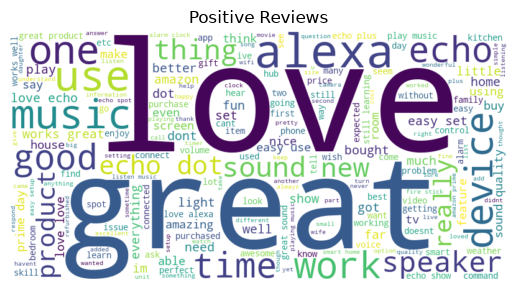

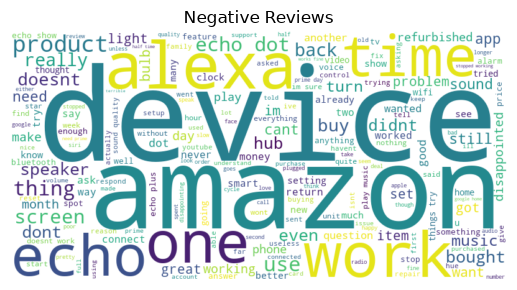

In [58]:
positive_wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_reviews)

plt.figure(figsize=(6,3))

plt.imshow(positive_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews")

plt.tight_layout()
plt.savefig("../assets/positive_wordcloud.png", dpi=300)

plt.show()

negative_wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_reviews)

plt.figure(figsize=(6,3))

plt.imshow(negative_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews")

plt.tight_layout()
plt.savefig("../assets/negative_wordcloud.png", dpi=300)

plt.show()

### Display the Word Clouds Side by Side

The positive and negative Word Clouds are displayed side by side for easy comparison.

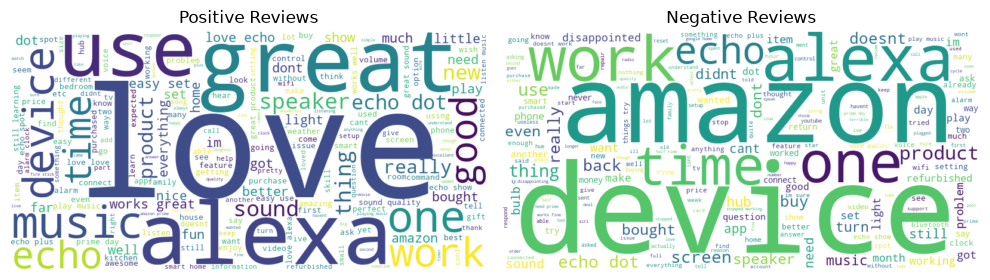

In [54]:
plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
plt.imshow(positive_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews")

plt.subplot(1,2,2)
plt.imshow(negative_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews")

plt.tight_layout()
plt.savefig("../assets/wordclouds.png")
plt.show()

### Observations

- The positive Word Cloud highlights the words that appear most frequently in positive customer reviews.
- The negative Word Cloud highlights the words most commonly associated with negative customer experiences.
- Comparing both visualizations helps identify words that distinguish positive and negative sentiments.
- These visualizations provide intuitive insights before training machine learning models.

# Text Vectorization using TF-IDF

Machine learning algorithms cannot process raw text directly. Therefore, the cleaned reviews must be converted into numerical features. In this project, the **TF-IDF (Term Frequency–Inverse Document Frequency)** vectorization technique is used to transform text into a numerical representation that can be used for sentiment classification.

### Why TF-IDF?

TF-IDF was selected because it not only counts how often a word appears in a review but also reduces the importance of words that occur very frequently across all reviews. This allows the model to focus on more meaningful and discriminative words, which often leads to better performance in text classification tasks such as sentiment analysis.

In [24]:
# Create the TF-IDF Vectorizer
vectorizer = TfidfVectorizer()

# Transform the Reviews
X = vectorizer.fit_transform(df["cleaned_reviews"])

y = df["feedback"]

# Inspect the Feature Matrix
print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (3149, 4201)


### Observations

- The cleaned text has been successfully converted into numerical feature vectors.
- Each row represents one customer review.
- Each column represents a unique word from the vocabulary.
- These numerical features will be used to train machine learning models for sentiment classification.

# Train Text Classification Models

The dataset is divided into training and testing sets so that the models can learn from one portion of the data and be evaluated on unseen data. Two machine learning algorithms are trained for sentiment classification:

- **Multinomial Naive Bayes**
- **Logistic Regression**

Using multiple models allows us to compare their performance and select the best one for deployment.

In [40]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Balance
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (2519, 4201)
Testing Set : (630, 4201)


### Train the Multinomial Naive Bayes Model

Multinomial Naive Bayes is commonly used for text classification because it works well with word-frequency features such as TF-IDF. It is simple, fast, and performs well on many Natural Language Processing tasks.

In [26]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[ 193.,2326.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-2.57,-0.08]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 4201)","[[0. ,0. ,0. ,...,0.52,0.19,0. ], [0.21,0. ,0.39,...,0. ,0. ,0.19]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 4201)","[[-8.49,-8.49,-8.49,...,-8.07,-8.31,-8.49], [-9.08,-9.28,-8.95,...,-9.28,-9.28,-9.11]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4201


### Train the Logistic Regression Model

Logistic Regression is a supervised learning algorithm used for binary classification problems. It is widely used in sentiment analysis because it performs well with high-dimensional text data represented using TF-IDF.

In [41]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

lr_model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

### Generate Predictions

After training, both models are used to predict the sentiments of the reviews in the testing dataset.

In [42]:
nb_predictions = nb_model.predict(X_test)

lr_predictions = lr_model.predict(X_test)

### Observations

- The dataset has been successfully divided into training and testing sets.
- Two different machine learning models have been trained using the TF-IDF feature vectors.
- Predictions have been generated for both models and will be evaluated in the next section using classification metrics and confusion matrices.

# Model Evaluation

The trained models are evaluated using multiple classification metrics to measure their performance on unseen data. A confusion matrix is generated for each model to visualize the number of correct and incorrect predictions. Finally, the performance of both models is compared to identify the best model for deployment.

### Evaluate the Multinomial Naive Bayes Model

The performance of the Multinomial Naive Bayes model is evaluated using accuracy, a classification report, and a confusion matrix.

In [43]:
nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Naive Bayes Accuracy:", round(nb_accuracy, 4))
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    nb_predictions,
    zero_division=0
))  # Remove Warnings (as positive reviews are much more)

Naive Bayes Accuracy: 0.9206

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.02      0.04        51
           1       0.92      1.00      0.96       579

    accuracy                           0.92       630
   macro avg       0.96      0.51      0.50       630
weighted avg       0.93      0.92      0.88       630



### Confusion Matrix – Multinomial Naive Bayes

The confusion matrix summarizes the model's predictions by showing correctly and incorrectly classified positive and negative reviews.

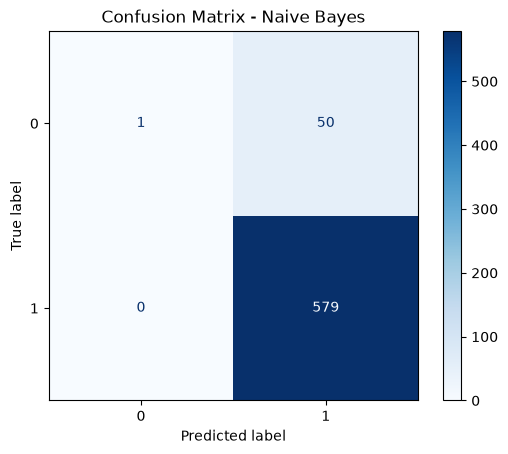

In [46]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_predictions,
    cmap="Blues"
)

plt.title("Confusion Matrix - Naive Bayes")
plt.show()

### Evaluate the Logistic Regression Model

The Logistic Regression model is evaluated using the same performance metrics to enable a fair comparison with the Naive Bayes model.

In [44]:
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", round(lr_accuracy, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy: 0.9222

Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.75      0.61        51
           1       0.98      0.94      0.96       579

    accuracy                           0.92       630
   macro avg       0.75      0.84      0.78       630
weighted avg       0.94      0.92      0.93       630



### Confusion Matrix – Logistic Regression

The confusion matrix illustrates the prediction performance of the Logistic Regression model by comparing actual and predicted sentiment labels.

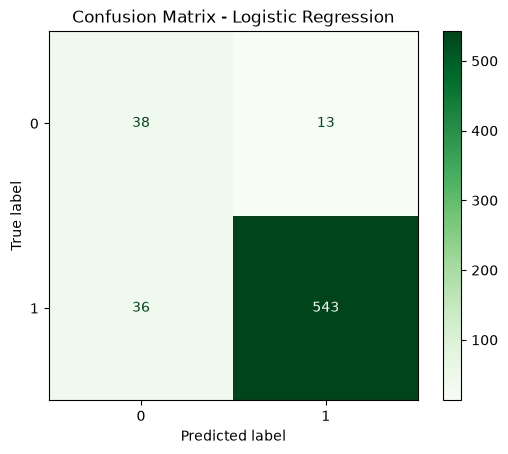

In [45]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_predictions,
    cmap="Greens"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Model Performance Comparison

The accuracy scores of both models are compared using a bar chart. This visualization helps identify the model that performs better for sentiment classification.

In [52]:
final_results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        round(nb_accuracy, 4),
        round(lr_accuracy, 4)
    ],
    "Negative Recall": [
        0.02,
        0.75
    ],
    "Negative F1-Score": [
        0.04,
        0.61
    ]
})

final_results

,Model,Accuracy,Negative Recall,Negative F1-Score
0,Multinomial Naive Bayes,0.9206,0.02,0.04
1,Logistic Regression,0.9222,0.75,0.61


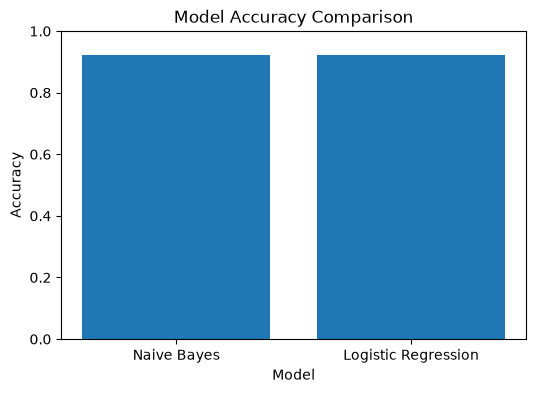

In [48]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()

### Observations

- Both models achieved an accuracy above 92% on the testing dataset.
- Although Multinomial Naive Bayes achieved high accuracy, it struggled to correctly identify negative reviews, resulting in a very low recall for the negative class.
- Logistic Regression provided a better balance between precision and recall, particularly for the minority (negative) class.
- Based on the overall evaluation metrics, Logistic Regression was selected as the final model for deployment in the Streamlit application.

# Save the Best Model

Based on the evaluation results, Logistic Regression demonstrated the best overall performance and was selected for deployment. The trained model and the TF-IDF vectorizer are saved so they can be loaded into the Streamlit application for real-time sentiment prediction.

In [51]:
joblib.dump(lr_model, "../models/sentiment_model.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


# Project Summary

This project applied Natural Language Processing (NLP) techniques to classify Amazon customer reviews as positive or negative. The reviews were preprocessed by removing noise, punctuation, numbers, and English stopwords before being converted into numerical features using the TF-IDF vectorization technique.

Two machine learning models—Multinomial Naive Bayes and Logistic Regression—were trained and evaluated using accuracy, classification reports, and confusion matrices. Due to the imbalanced nature of the dataset, Logistic Regression was trained with balanced class weights to improve its ability to classify minority-class (negative) reviews.

Based on the evaluation results, Logistic Regression achieved the best overall performance and was selected for deployment in the Streamlit application.